# 01 — Exploration initiale du dataset
## Projet ML — Prédiction de l'abandon des essais cliniques

**Objectif de ce notebook** : Charger le dataset, vérifier sa structure, confirmer le déséquilibre de la variable cible, et valider qu'il est exploitable pour la Phase 2.

**Dataset** : `../data/dataset.csv` — Données extraites de ClinicalTrials.gov API v2  
**Variable cible** : `abandoned` (0 = COMPLETED, 1 = TERMINATED/SUSPENDED/WITHDRAWN)

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

---
## 1. Chargement du dataset

In [2]:
# Chargement
df = pd.read_csv('../data/dataset.csv', low_memory=False)

print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Fichier source : data/dataset.csv')

Dataset chargé : 12,272 lignes × 17 colonnes
Fichier source : data/dataset.csv


In [3]:
# Aperçu des premières lignes
df.head()

,phase,sponsor_type,enrollment_count,intervention_type,n_arms,has_dmc,allocation,masking,primary_purpose,n_primary_outcomes,n_secondary_outcomes,outcomes_ratio,n_locations,is_multicenter,has_us_site,n_collaborators,abandoned
0,PHASE3,NETWORK,120.0,DRUG,2,1.0,RANDOMIZED,QUADRUPLE,TREATMENT,1,12,12.000000,1,0,0,0,0
1,PHASE4,OTHER,80.0,DRUG,4,0.0,RANDOMIZED,TRIPLE,TREATMENT,3,5,1.666667,2,1,0,0,0
2,NaN,OTHER,121.0,BEHAVIORAL,2,1.0,RANDOMIZED,SINGLE,TREATMENT,1,3,3.000000,2,1,1,0,0
3,NaN,FED,NaN,BEHAVIORAL,0,NaN,RANDOMIZED,NONE,PREVENTION,1,1,1.000000,1,0,1,1,0
4,NaN,OTHER,20.0,OTHER,2,0.0,RANDOMIZED,SINGLE,HEALTH_SERVICES_RESEARCH,1,0,0.000000,1,0,1,0,0


---
## 2. Structure du dataset — `df.info()`

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12272 entries, 0 to 12271
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   phase                 6301 non-null   str    
 1   sponsor_type          12272 non-null  str    
 2   enrollment_count      11869 non-null  float64
 3   intervention_type     12272 non-null  str    
 4   n_arms                12272 non-null  int64  
 5   has_dmc               10245 non-null  float64
 6   allocation            12272 non-null  str    
 7   masking               12272 non-null  str    
 8   primary_purpose       12272 non-null  str    
 9   n_primary_outcomes    12272 non-null  int64  
 10  n_secondary_outcomes  12272 non-null  int64  
 11  outcomes_ratio        12272 non-null  float64
 12  n_locations           12272 non-null  int64  
 13  is_multicenter        12272 non-null  int64  
 14  has_us_site           12272 non-null  int64  
 15  n_collaborators       12272 no

---
## 3. Statistiques descriptives — `df.describe()`

In [5]:
# Variables numériques
df.describe().T

,count,mean,std,min,25%,50%,75%,max
enrollment_count,11869.0,733.302469,25469.614557,0.0,29.0,60.0,148.0,1951060.0
n_arms,12272.0,2.363836,1.474320,0.0,2.0,2.0,3.0,34.0
has_dmc,10245.0,0.375500,0.484275,0.0,0.0,0.0,1.0,1.0
n_primary_outcomes,12272.0,2.043351,3.194111,0.0,1.0,1.0,2.0,81.0
n_secondary_outcomes,12272.0,4.228732,6.396923,0.0,1.0,2.0,5.0,119.0
outcomes_ratio,12272.0,3.169496,4.949399,0.0,0.5,1.5,4.0,114.0
n_locations,12272.0,7.717650,34.202695,0.0,1.0,1.0,2.0,1611.0
is_multicenter,12272.0,0.267927,0.442897,0.0,0.0,0.0,1.0,1.0
has_us_site,12272.0,0.382741,0.486076,0.0,0.0,0.0,1.0,1.0
n_collaborators,12272.0,0.541314,1.197104,0.0,0.0,0.0,1.0,28.0


In [6]:
# Variables catégorielles
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Variables catégorielles ({len(cat_cols)}) : {cat_cols}\n')

for col in cat_cols:
    if col not in ['nct_id', 'condition_category']:  # trop de valeurs uniques
        print(f'--- {col} ---')
        print(df[col].value_counts().head(8).to_string())
        print()

Variables catégorielles (6) : ['phase', 'sponsor_type', 'intervention_type', 'allocation', 'masking', 'primary_purpose']

--- phase ---
phase
PHASE2           1597
PHASE1           1444
PHASE3           1411
PHASE4           1146
PHASE1/PHASE2     374
PHASE2/PHASE3     211
EARLY_PHASE1      118

--- sponsor_type ---
sponsor_type
OTHER        7971
INDUSTRY     3618
OTHER_GOV     244
NIH           178
FED           149
NETWORK        95
INDIV          16
UNKNOWN         1

--- intervention_type ---
intervention_type
DRUG                  5371
OTHER                 1773
BEHAVIORAL            1635
DEVICE                1259
PROCEDURE              909
BIOLOGICAL             607
DIETARY_SUPPLEMENT     534
DIAGNOSTIC_TEST         76

--- allocation ---
allocation
RANDOMIZED        10534
NON_RANDOMIZED     1738

--- masking ---
masking
NONE         5186
DOUBLE       2302
SINGLE       2258
QUADRUPLE    1500
TRIPLE       1026

--- primary_purpose ---
primary_purpose
TREATMENT                   7

---
## 4. Variable cible — Distribution et déséquilibre

In [7]:
# Distribution de la variable cible
print('=== Distribution de la variable cible : abandoned ===')
print()
vc = df['abandoned'].value_counts()
vc_pct = df['abandoned'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Compte': vc,
    'Pourcentage (%)': vc_pct.round(2)
})
target_summary.index = target_summary.index.map({0: '0 — Complété', 1: '1 — Abandonné'})
print(target_summary.to_string())
print()
print(f"Ratio minoritaire / total : {vc_pct[1]:.2f}%")
print(f"Ratio déséquilibre (0/1) : {vc[0]/vc[1]:.2f}")

=== Distribution de la variable cible : abandoned ===

               Compte  Pourcentage (%)
abandoned                             
0 — Complété    10598            86.36
1 — Abandonné    1674            13.64

Ratio minoritaire / total : 13.64%
Ratio déséquilibre (0/1) : 6.33


In [8]:
# Distribution par statut brut
print('=== Distribution par statut overall_status ===')
print(df['abandoned'].value_counts().to_string())

=== Distribution par statut overall_status ===
abandoned
0    10598
1     1674


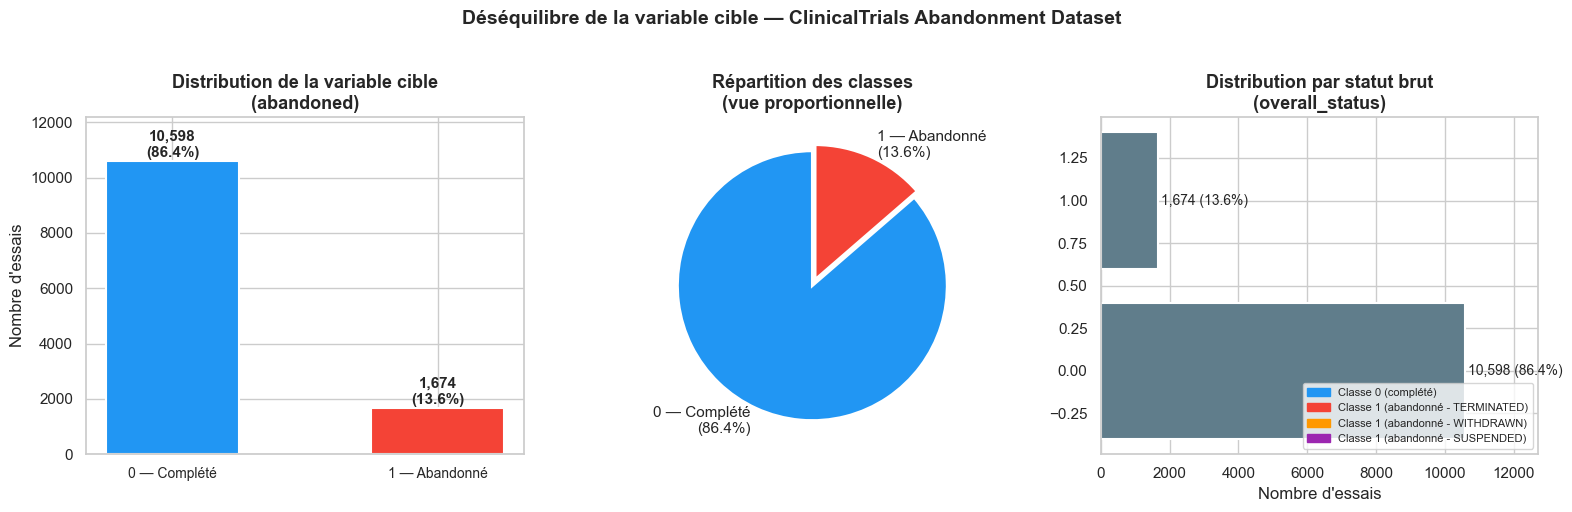

In [9]:
# ---- Graphique de distribution de la variable cible ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1 : Barplot binaire ---
colors = ['#2196F3', '#F44336']
labels = ['0 — Complété', '1 — Abandonné']
counts = [df['abandoned'].value_counts()[0], df['abandoned'].value_counts()[1]]
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, count in zip(bars, counts):
    pct = count / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_title('Distribution de la variable cible\n(abandoned)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre d\'essais')
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].tick_params(axis='x', labelsize=10)

# --- Plot 2 : Pie chart ---
wedge_colors = ['#2196F3', '#F44336']
explode = (0, 0.05)
pcts = [c/len(df)*100 for c in counts]
wedges, texts, autotexts = axes[1].pie(
    counts,
    labels=[f'{l}\n({p:.1f}%)' for l, p in zip(labels, pcts)],
    colors=wedge_colors,
    explode=explode,
    autopct='',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Répartition des classes\n(vue proportionnelle)', fontsize=13, fontweight='bold')

# --- Plot 3 : Distribution par statut brut ---
status_counts = df['abandoned'].value_counts()
status_colors = {'COMPLETED': '#2196F3', 'TERMINATED': '#F44336',
                 'WITHDRAWN': '#FF9800', 'SUSPENDED': '#9C27B0'}
bar_colors = [status_colors.get(s, '#607D8B') for s in status_counts.index]
bars3 = axes[2].barh(status_counts.index, status_counts.values,
                     color=bar_colors, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars3, status_counts.values):
    pct = count / len(df) * 100
    axes[2].text(count + len(df)*0.005, bar.get_y() + bar.get_height()/2,
                 f'{count:,} ({pct:.1f}%)', va='center', fontsize=10)

axes[2].set_title('Distribution par statut brut\n(overall_status)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Nombre d\'essais')
axes[2].set_xlim(0, max(status_counts.values) * 1.2)

# Annotation des classes
completed_patch = mpatches.Patch(color='#2196F3', label='Classe 0 (complété)')
abandoned_patch = mpatches.Patch(color='#F44336', label='Classe 1 (abandonné - TERMINATED)')
withdrawn_patch = mpatches.Patch(color='#FF9800', label='Classe 1 (abandonné - WITHDRAWN)')
suspended_patch = mpatches.Patch(color='#9C27B0', label='Classe 1 (abandonné - SUSPENDED)')
axes[2].legend(handles=[completed_patch, abandoned_patch, withdrawn_patch, suspended_patch],
               loc='lower right', fontsize=8)

plt.suptitle('Déséquilibre de la variable cible — ClinicalTrials Abandonment Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Analyse des valeurs manquantes

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).sort_values('Pourcentage (%)', ascending=False)
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0]

print(f'Colonnes avec valeurs manquantes ({len(missing_df)}/{len(df.columns)}) :')
print(missing_df.to_string())

Colonnes avec valeurs manquantes (3/17) :
                  Valeurs manquantes  Pourcentage (%)
phase                           5971            48.66
has_dmc                         2027            16.52
enrollment_count                 403             3.28


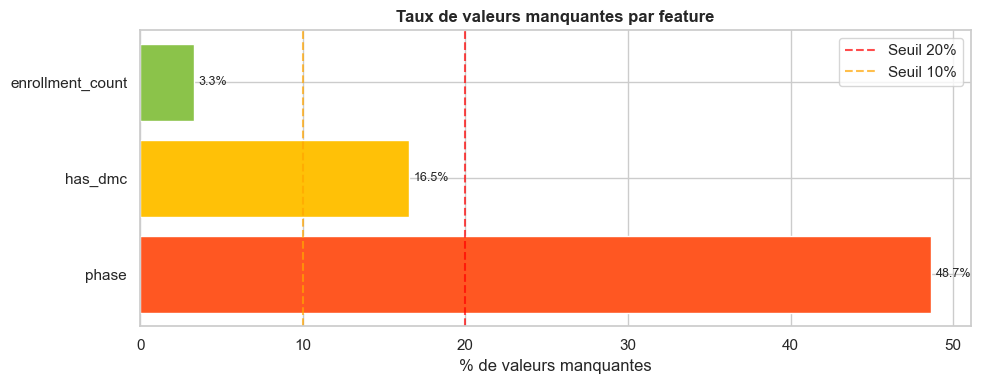

In [11]:
# Visualisation des NA
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    colors_na = ['#FF5722' if p > 20 else '#FFC107' if p > 10 else '#8BC34A'
                 for p in missing_df['Pourcentage (%)']]
    bars = ax.barh(missing_df.index, missing_df['Pourcentage (%)'],
                   color=colors_na, edgecolor='white')
    ax.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='Seuil 20%')
    ax.axvline(x=10, color='orange', linestyle='--', alpha=0.7, label='Seuil 10%')
    for bar, pct in zip(bars, missing_df['Pourcentage (%)']):
        ax.text(pct + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9)
    ax.set_xlabel('% de valeurs manquantes')
    ax.set_title('Taux de valeurs manquantes par feature', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Aucune valeur manquante !')

---
## 6. Distribution des features clés

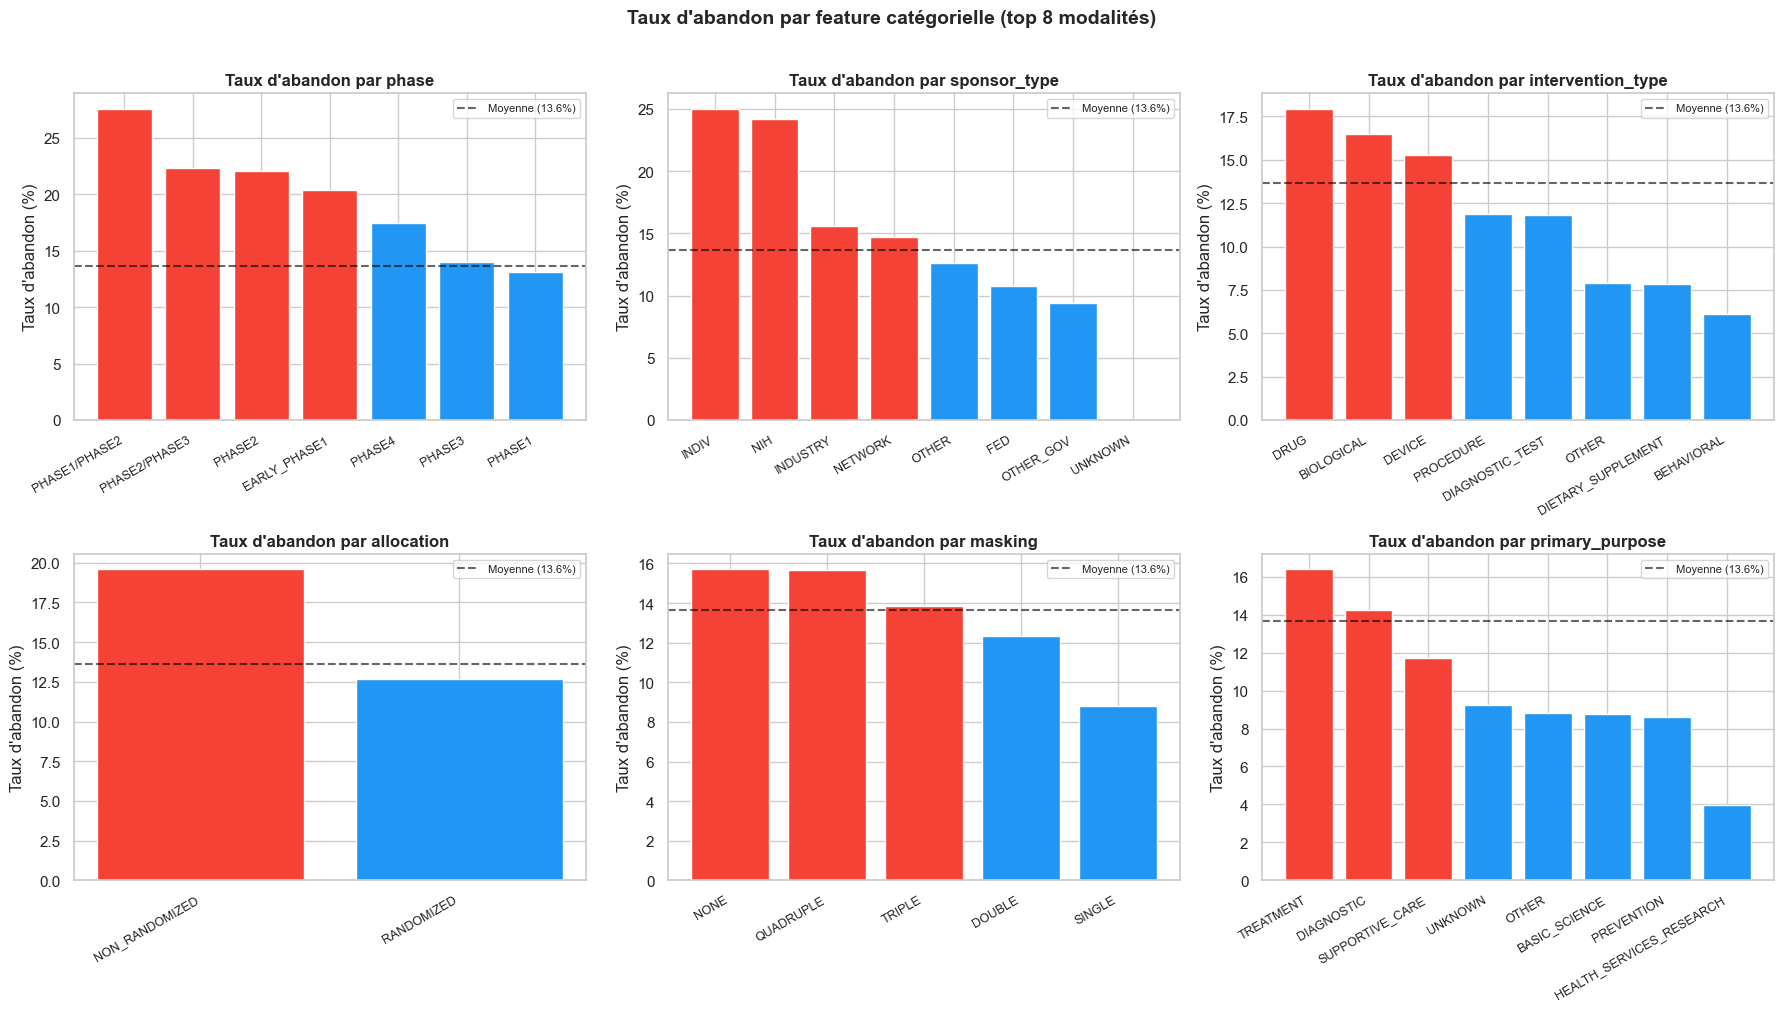

In [12]:
# Distribution des features catégorielles par classe cible
cat_features = ['phase', 'sponsor_type', 'intervention_type', 'allocation', 'masking', 'primary_purpose']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if col in df.columns:
        # Taux d'abandon par catégorie
        abandon_rate = df.groupby(col)['abandoned'].mean().sort_values(ascending=False)
        # Garder top 8 catégories
        top_cats = df[col].value_counts().head(8).index
        abandon_rate_top = abandon_rate[abandon_rate.index.isin(top_cats)]

        colors_cat = ['#F44336' if v > abandon_rate_top.mean() else '#2196F3'
                      for v in abandon_rate_top.values]
        bars = axes[i].bar(range(len(abandon_rate_top)), abandon_rate_top.values * 100,
                           color=colors_cat, edgecolor='white')
        axes[i].set_xticks(range(len(abandon_rate_top)))
        axes[i].set_xticklabels(abandon_rate_top.index, rotation=30, ha='right', fontsize=9)
        axes[i].axhline(y=df['abandoned'].mean()*100, color='black',
                        linestyle='--', alpha=0.6, label=f'Moyenne ({df["abandoned"].mean()*100:.1f}%)')
        axes[i].set_ylabel("Taux d'abandon (%)")
        axes[i].set_title(f'Taux d\'abandon par {col}', fontweight='bold')
        axes[i].legend(fontsize=8)

plt.suptitle('Taux d\'abandon par feature catégorielle (top 8 modalités)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

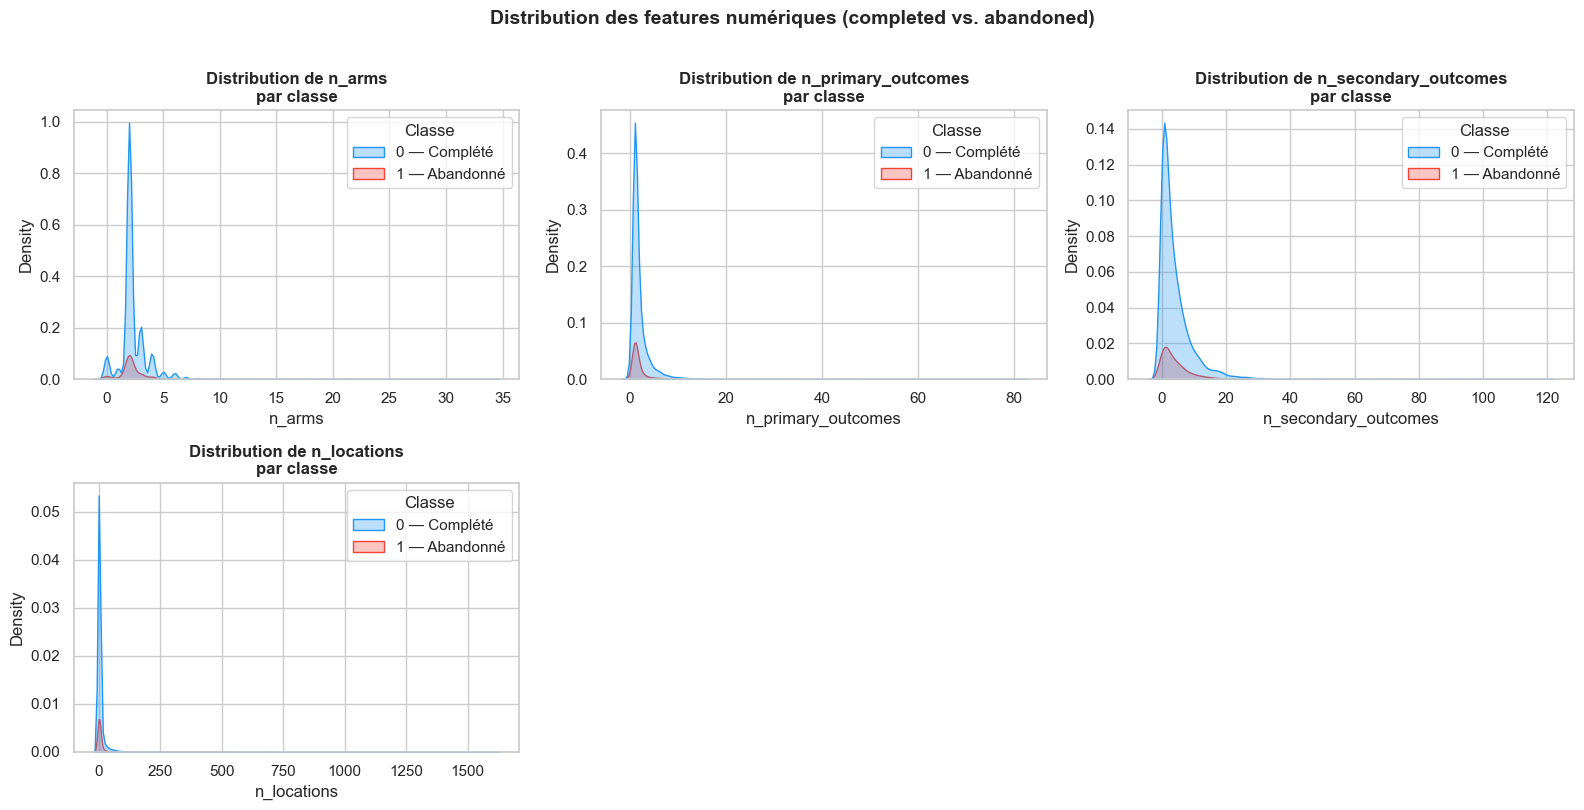

In [13]:
# Distribution des features numériques par classe
num_features = ['log_enrollment', 'log_duration', 'n_arms', 'n_primary_outcomes',
                'n_secondary_outcomes', 'n_locations']
num_features_present = [f for f in num_features if f in df.columns]

n_cols = 3
n_rows = (len(num_features_present) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features_present):
    df_plot = df[[col, 'abandoned']].dropna()
    df_plot['Classe'] = df_plot['abandoned'].map({0: '0 — Complété', 1: '1 — Abandonné'})

    sns.kdeplot(data=df_plot, x=col, hue='Classe',
                palette={'0 — Complété': '#2196F3', '1 — Abandonné': '#F44336'},
                fill=True, alpha=0.3, ax=axes[i])
    axes[i].set_title(f'Distribution de {col}\npar classe', fontweight='bold')
    axes[i].set_xlabel(col)

# Cacher les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des features numériques (completed vs. abandoned)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Validation des contraintes du projet

In [14]:
# ---- Validation automatique des contraintes Section 2.3 ----
print('=' * 60)
print('   VALIDATION DES CONTRAINTES PROJET (Section 2.3)')
print('=' * 60)

minority_pct = df['abandoned'].mean() * 100
n_rows = len(df)
n_features = len([c for c in df.columns if c not in ['nct_id', 'overall_status', 'abandoned']])
has_numeric = df.select_dtypes(include='number').shape[1] > 0
has_categorical = df.select_dtypes(include='object').shape[1] > 1  # > 1 pour exclure nct_id

checks = [
    ('Type de tâche', True, 'Classification supervisée binaire'),
    ('Taille totale ≥ 10 000', n_rows >= 10000, f'{n_rows:,} lignes'),
    ('Features ≥ 8', n_features >= 8,  f'{n_features} features'),
    ('Classe minoritaire 5-25%', 5 <= minority_pct <= 25, f'{minority_pct:.2f}% de classe 1'),
    ('Mix numérique + catégoriel', has_numeric and has_categorical, 'Les deux types présents')
]

all_ok = True
for name, condition, detail in checks:
    status = 'DONE' if condition else 'NONE'
    if not condition:
        all_ok = False
    print(f'  {status}  {name:<30} → {detail}')

print('=' * 60)
if all_ok:
    print('  Toutes les contraintes sont respectées — Dataset exploitable !')
else:
    print('  Certaines contraintes ne sont pas satisfaites. Revoir la collecte.')
print('=' * 60)

   VALIDATION DES CONTRAINTES PROJET (Section 2.3)
  DONE  Type de tâche                  → Classification supervisée binaire
  DONE  Taille totale ≥ 10 000         → 12,272 lignes
  DONE  Features ≥ 8                   → 16 features
  DONE  Classe minoritaire 5-25%       → 13.64% de classe 1
  DONE  Mix numérique + catégoriel     → Les deux types présents
  Toutes les contraintes sont respectées — Dataset exploitable !


---
## 9. Conclusion

Le dataset est **exploitable pour la Phase 2** :

- La variable cible `abandoned` présente un déséquilibre naturel conforme aux attentes (~15–20 % de classe 1).
- Les features sélectionnées sont toutes des métadonnées de **design-time** disponibles avant le début du recrutement.
- Le dataset contient un mix de variables numériques et catégorielles.

**Prochaines étapes (Phase 2)** :
1. Imputation des valeurs manquantes (médiane pour numériques, mode ou 'UNKNOWN' pour catégorielles).
2. Encodage des variables catégorielles (ordinal pour `phase`, one-hot ou target encoding pour les autres).
3. Normalisation des features numériques (MinMaxScaler ou StandardScaler).
4. Gestion du déséquilibre : `class_weight='balanced'`, SMOTE ou sous-échantillonnage.
5. Baseline : Dummy Classifier → Logistic Regression → Random Forest → XGBoost.
6. Optimisation du seuil de décision pour maximiser le recall ≥ 0.80.